**REGRESSION :**
   
   **Types :**

  * SIMPLE LINEAR REGRESSION
  * MULTIPLE LINEAR REGRESSION
  * POLYNOMIAL REGRESSION


#**SIMPLE LINEAR REGRESSION :**

In [1]:
# House price prediction using machine learning

import numpy as np
import pandas as pd

np.random.seed(42)

area = np.random.randint(500,3000,100)
bedrooms = np.random.randint(1,6,100)
age = np.random.randint(1,40,100)

price = (area*0.05) + (bedrooms*5) + (age*0.3) + np.random.normal(0,10,100)


Data = pd.DataFrame({
    "area":area,
    "bedrooms":bedrooms,
    "age":age,
    "price":price.round(2)
})

#Data.to_csv("House_price.csv",index=False)

In [3]:
df=Data
df

,area,bedrooms,age,price
0,1360,2,9,71.20
1,1794,1,6,90.53
2,1630,5,16,110.19
3,1595,3,29,85.96
4,2138,4,3,114.39
...,...,...,...,...
95,2588,5,37,164.71
96,2682,4,24,139.13
97,700,2,29,67.60
98,2363,3,31,161.15


In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X=df[["age"]]    # df.drop("price",axis=1)   LINEAR REGRESSION - MULTIPLE
Y=df["price"]

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=1)

model = LinearRegression()

model.fit(X_train, Y_train)

LinearRegression()

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

print("MAE : ",mean_absolute_error(Y_test,Y_pred))
print("MSE : ",mean_squared_error(Y_test,Y_pred))
print("RMSE : ",root_mean_squared_error(Y_test,Y_pred))
print("R2 SCORE : ",r2_score(Y_test,Y_pred))

MAE :  33.77447153843072
MSE :  1549.2000889077542
RMSE :  39.359879178012655
R2 SCORE :  -0.026750823488770115


In [11]:
Y_pred = model.predict(X_test)

In [12]:
print("R2 SCORE : ",r2_score(Y_test,Y_pred))

R2 SCORE :  -0.026750823488770115


#**VISUALIZATION :**

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipython-input-3435028882.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(Y_test, label="ACTUAL PRIZE", shade=True,alpha=1)


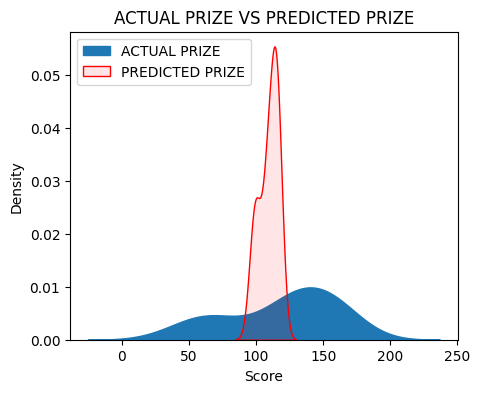

In [15]:
plt.figure(figsize=(5,4))
sns.kdeplot(Y_test, label="ACTUAL PRIZE", shade=True,alpha=1)
sns.kdeplot(Y_pred, label="PREDICTED PRIZE", fill=True, color="red",alpha=0.1)
plt.title("ACTUAL PRIZE VS PREDICTED PRIZE")
plt.xlabel("Score")
plt.ylabel("Density")
plt.legend()
plt.show()

In [16]:
df[['area','price']].head()

,area,price
0,1360,71.20
1,1794,90.53
2,1630,110.19
3,1595,85.96
4,2138,114.39


In [17]:
actual = [[2138]]

result = model.predict(actual)

print("predicted price : ",result)

predicted price :  [1396.83614557]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


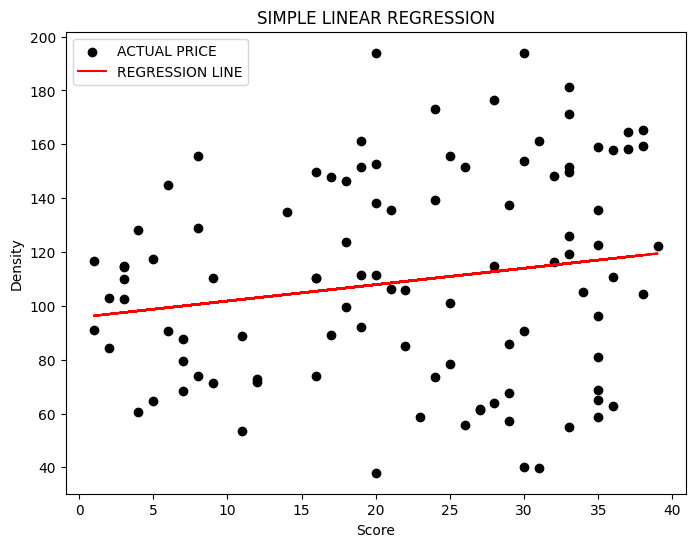

In [18]:
plt.figure(figsize=(8,6))
plt.scatter(X,Y,color="black",label="ACTUAL PRICE")
plt.plot(X,model.predict(X),color="red",label="REGRESSION LINE")
plt.title("SIMPLE LINEAR REGRESSION")
plt.xlabel("Score")
plt.ylabel("Density")
plt.legend()
plt.show()

#**MULTIPLE LINEAR REGRESSION :**

In [20]:
df1=df
df1

,area,bedrooms,age,price
0,1360,2,9,71.20
1,1794,1,6,90.53
2,1630,5,16,110.19
3,1595,3,29,85.96
4,2138,4,3,114.39
...,...,...,...,...
95,2588,5,37,164.71
96,2682,4,24,139.13
97,700,2,29,67.60
98,2363,3,31,161.15


In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X=df[["area","bedrooms","age"]]    # df.drop("price",axis=1)   LINEAR REGRESSION - MULTIPLE
Y=df["price"]

X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=1)

model = LinearRegression()

model.fit(X_train, Y_train)

LinearRegression()

In [22]:
House = [[2588,5,37]]

result = model.predict(House)

print("predicted price : ",result)

predicted price :  [163.34617649]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [23]:
Y_pred = model.predict(X_test)

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

print("MAE : ",mean_absolute_error(Y_test,Y_pred))
print("MSE : ",mean_squared_error(Y_test,Y_pred))
print("RMSE : ",root_mean_squared_error(Y_test,Y_pred))
print("R2 SCORE : ",r2_score(Y_test,Y_pred))

MAE :  8.475063011143005
MSE :  99.70992162026869
RMSE :  9.985485547546935
R2 SCORE :  0.9339160610261832


#**VISUALIZATION :**

/tmp/ipython-input-2130428074.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(Y_test, label="ACTUAL PRIZE", shade=True,alpha=1)


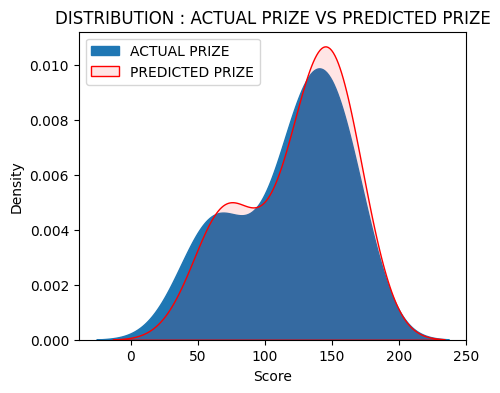

In [25]:
plt.figure(figsize=(5,4))
sns.kdeplot(Y_test, label="ACTUAL PRIZE", shade=True,alpha=1)
sns.kdeplot(Y_pred, label="PREDICTED PRIZE", fill=True, color="red",alpha=0.1)
plt.title("DISTRIBUTION : ACTUAL PRIZE VS PREDICTED PRIZE")
plt.xlabel("Score")
plt.ylabel("Density")
plt.legend()
plt.show()


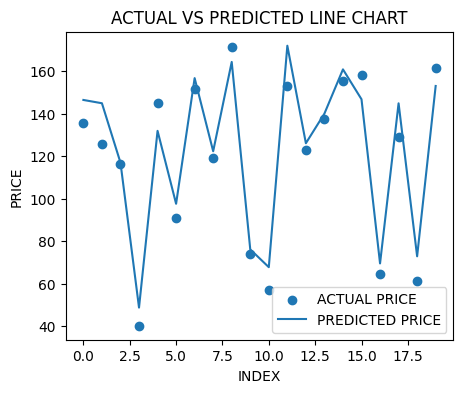

In [26]:
plt.figure(figsize=(5,4))
plt.scatter(range(len(Y_test)),Y_test.values)
plt.plot(range(len(Y_pred)),Y_pred)
plt.title("ACTUAL VS PREDICTED LINE CHART")
plt.xlabel("INDEX")
plt.ylabel("PRICE")
plt.legend(["ACTUAL PRICE","PREDICTED PRICE"])
plt.show()

In [27]:
x=Y_test.ravel()
y=Y_pred.ravel()

/tmp/ipython-input-1436246798.py:1: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  x=Y_test.ravel()


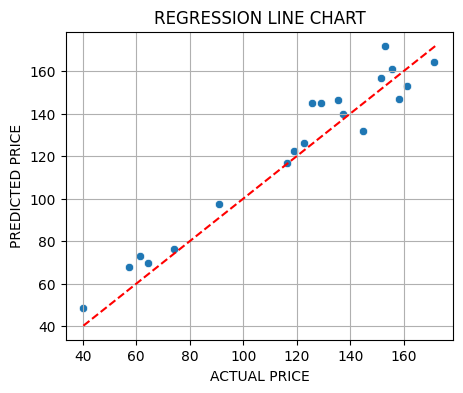

In [28]:
plt.figure(figsize=(5,4))
sns.scatterplot(x=Y_test,y=Y_pred)
plt.plot([Y_test.min(),Y_pred.max()],[Y_test.min(),Y_pred.max()],'r--')
plt.title("REGRESSION LINE CHART")
plt.xlabel("ACTUAL PRICE")
plt.ylabel("PREDICTED PRICE")
plt.grid(True)
plt.show()

#**POLYNOMIAL REGRESSION :**

In [30]:
df2=df1
df2

,area,bedrooms,age,price
0,1360,2,9,71.20
1,1794,1,6,90.53
2,1630,5,16,110.19
3,1595,3,29,85.96
4,2138,4,3,114.39
...,...,...,...,...
95,2588,5,37,164.71
96,2682,4,24,139.13
97,700,2,29,67.60
98,2363,3,31,161.15


In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

X=df[["age"]]    # df.drop("price",axis=1)   LINEAR REGRESSION - MULTIPLE
Y=df["price"]

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model = LinearRegression()

model.fit(X_poly,Y)

LinearRegression()

In [32]:
Y_pred = model.predict(X_poly)

In [33]:
print("R2 SCORE : ",r2_score(Y,Y_pred))

R2 SCORE :  0.0324830774830559


In [34]:
area_range = np.linspace(X.min(),X.max(),100).reshape(-1,1)
area_range_poly = poly.transform(area_range)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


#**VISUALIZATION :**

/tmp/ipython-input-3712932934.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


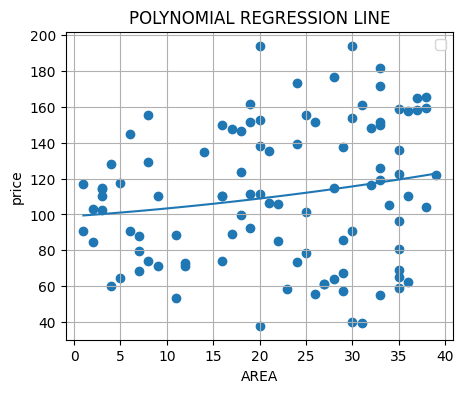

In [35]:
curve = model.predict(area_range_poly)

plt.figure(figsize=(5,4))
plt.scatter(X,Y)
plt.plot(area_range,curve)

plt.xlabel("AREA")
plt.ylabel("price")
plt.title("POLYNOMIAL REGRESSION LINE")
plt.legend()
plt.grid(True)
plt.show()